# **Exploratory Data Analysis**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [3]:

file_path = '/content/mutated_output_data (1).csv'  # Update with the correct file path
df = pd.read_csv(file_path)


In [4]:
df[:10]

,Atom,X,Y,Z,Force_X,Force_Y,Force_Z,Energy,Free_Energy
0,Ca,0.000000,1.599778,13.759834,0.009221,-0.039848,-0.136571,-182.801828,-182.305590
1,Ca,0.000000,12.919709,9.605922,-0.005846,0.105137,0.253160,-177.040086,-177.576361
2,Ca,2.296115,4.054680,11.682878,0.004165,-0.049165,-0.243269,-179.227290,-180.807655
3,Ca,2.296115,15.374611,11.682878,0.007951,0.140810,0.107379,-180.560644,-181.508926
4,Ca,0.000000,7.259744,11.682878,-0.007651,-0.125982,-0.215967,-184.987043,-185.958942
5,Ca,0.000000,18.579675,7.528966,-0.003623,0.046315,0.371094,-184.987284,-184.846837
6,Ca,2.296115,9.714645,9.605922,0.004514,-0.162888,0.215986,-185.966393,-187.553123
7,Ca,2.296115,21.034577,9.605922,-0.015739,0.010218,-0.090662,-177.885468,-178.732641
8,Ca,9.177640,1.590953,17.692838,0.004279,0.005173,-0.008314,-180.536079,-181.161683
9,Ca,0.000000,12.919709,13.759834,-0.001786,0.013785,-0.094612,-179.466504,-179.357595


In [5]:
# 2. Basic overview
print("===== DataFrame Info =====")
df.info()
print("\n===== First 5 Rows =====")
print(df.head())
print("\n===== Statistical Summary =====")
print(df.describe())
print("\n===== Atom Type Counts =====")
print(df['Atom'].value_counts())

===== DataFrame Info =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100610 entries, 0 to 100609
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Atom         100610 non-null  object 
 1   X            100610 non-null  float64
 2   Y            100610 non-null  float64
 3   Z            100610 non-null  float64
 4   Force_X      100610 non-null  float64
 5   Force_Y      100610 non-null  float64
 6   Force_Z      100610 non-null  float64
 7   Energy       100610 non-null  float64
 8   Free_Energy  100610 non-null  float64
dtypes: float64(8), object(1)
memory usage: 6.9+ MB

===== First 5 Rows =====
  Atom         X          Y          Z   Force_X   Force_Y   Force_Z  \
0   Ca  0.000000   1.599778  13.759834  0.009221 -0.039848 -0.136571   
1   Ca  0.000000  12.919709   9.605922 -0.005846  0.105137  0.253160   
2   Ca  2.296115   4.054680  11.682878  0.004165 -0.049165 -0.243269   
3   Ca  2.296115  15.374

In [6]:
# 3. Missing data analysis
missing = df.isnull().sum()
missing_perc = (missing / len(df)) * 100
print("\n===== Missing Data =====")
print(pd.DataFrame({'Missing Values': missing, 'Percent (%)': missing_perc}))



===== Missing Data =====
             Missing Values  Percent (%)
Atom                      0          0.0
X                         0          0.0
Y                         0          0.0
Z                         0          0.0
Force_X                   0          0.0
Force_Y                   0          0.0
Force_Z                   0          0.0
Energy                    0          0.0
Free_Energy               0          0.0


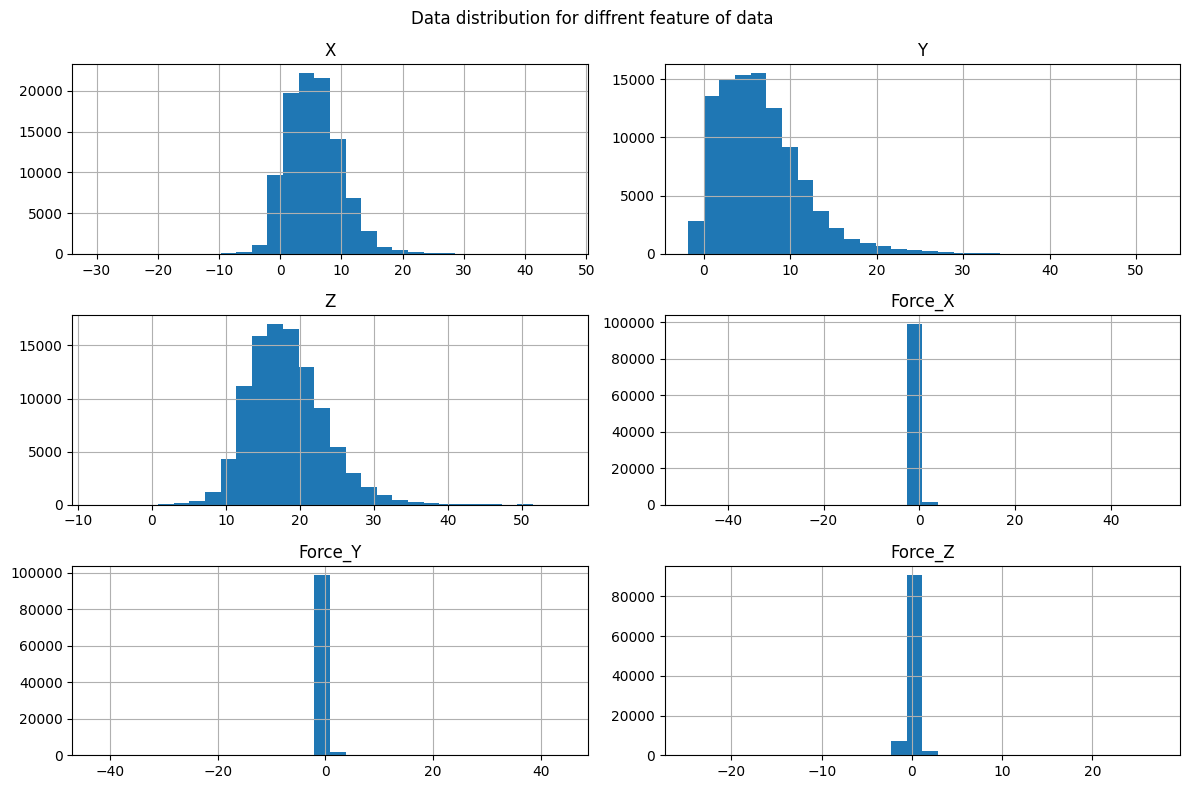

In [7]:
# 4. Histograms of numeric features
num_cols = ['X', 'Y', 'Z', 'Force_X', 'Force_Y', 'Force_Z']
df[num_cols].hist(bins=30, figsize=(12, 8))
plt.suptitle('Data distribution for diffrent feature of data ')
plt.tight_layout()
plt.show()


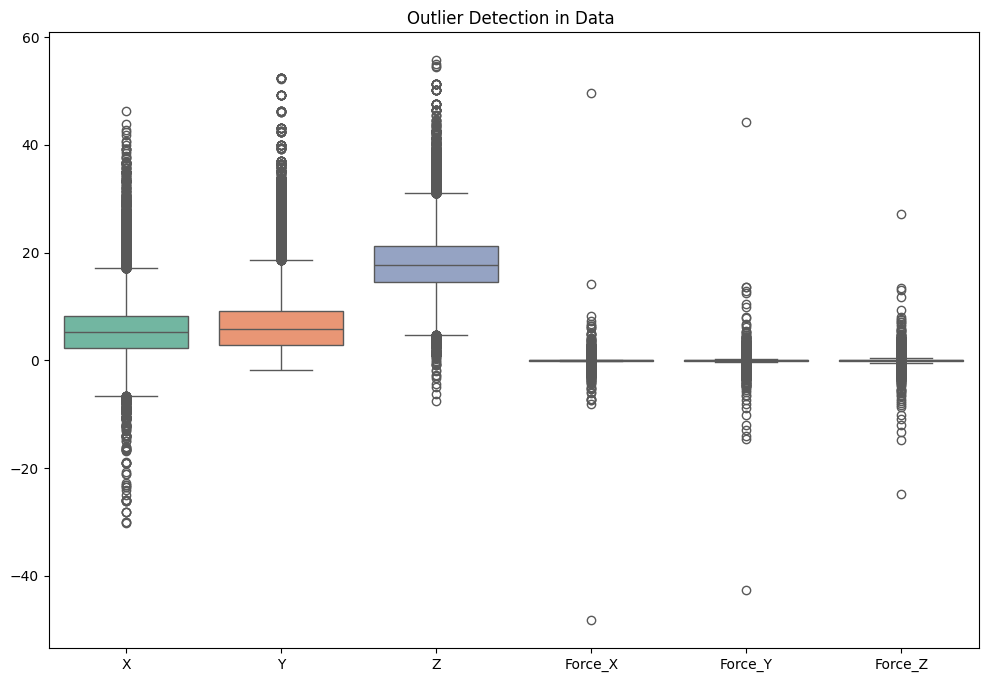

In [9]:
# 5. Boxplots to identify outliers
plt.figure(figsize=(12, 8))
sns.boxplot(data=df[num_cols], orient='v', palette="Set2")
plt.title('Outlier Detection in Data ')
plt.show()


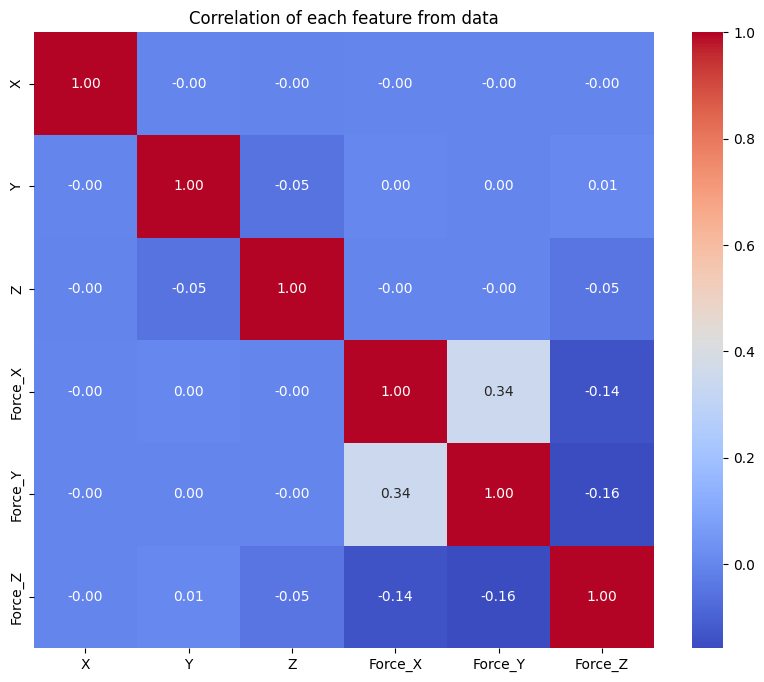

In [10]:
# 6. Correlation heatmap
corr = df[num_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation of each feature from data')
plt.show()




*   Detect Correlations & Collinearity-two features lie along a straight line (e.g. Force_X vs. Force_Y), they’re strongly coupled
*   Non-Linear Patterns- Force_Z only spikes beyond a certain Z-height—suggesting a threshold effect

*   Identify Outliers-Lone points far from the main cloud indicate unusual geometries






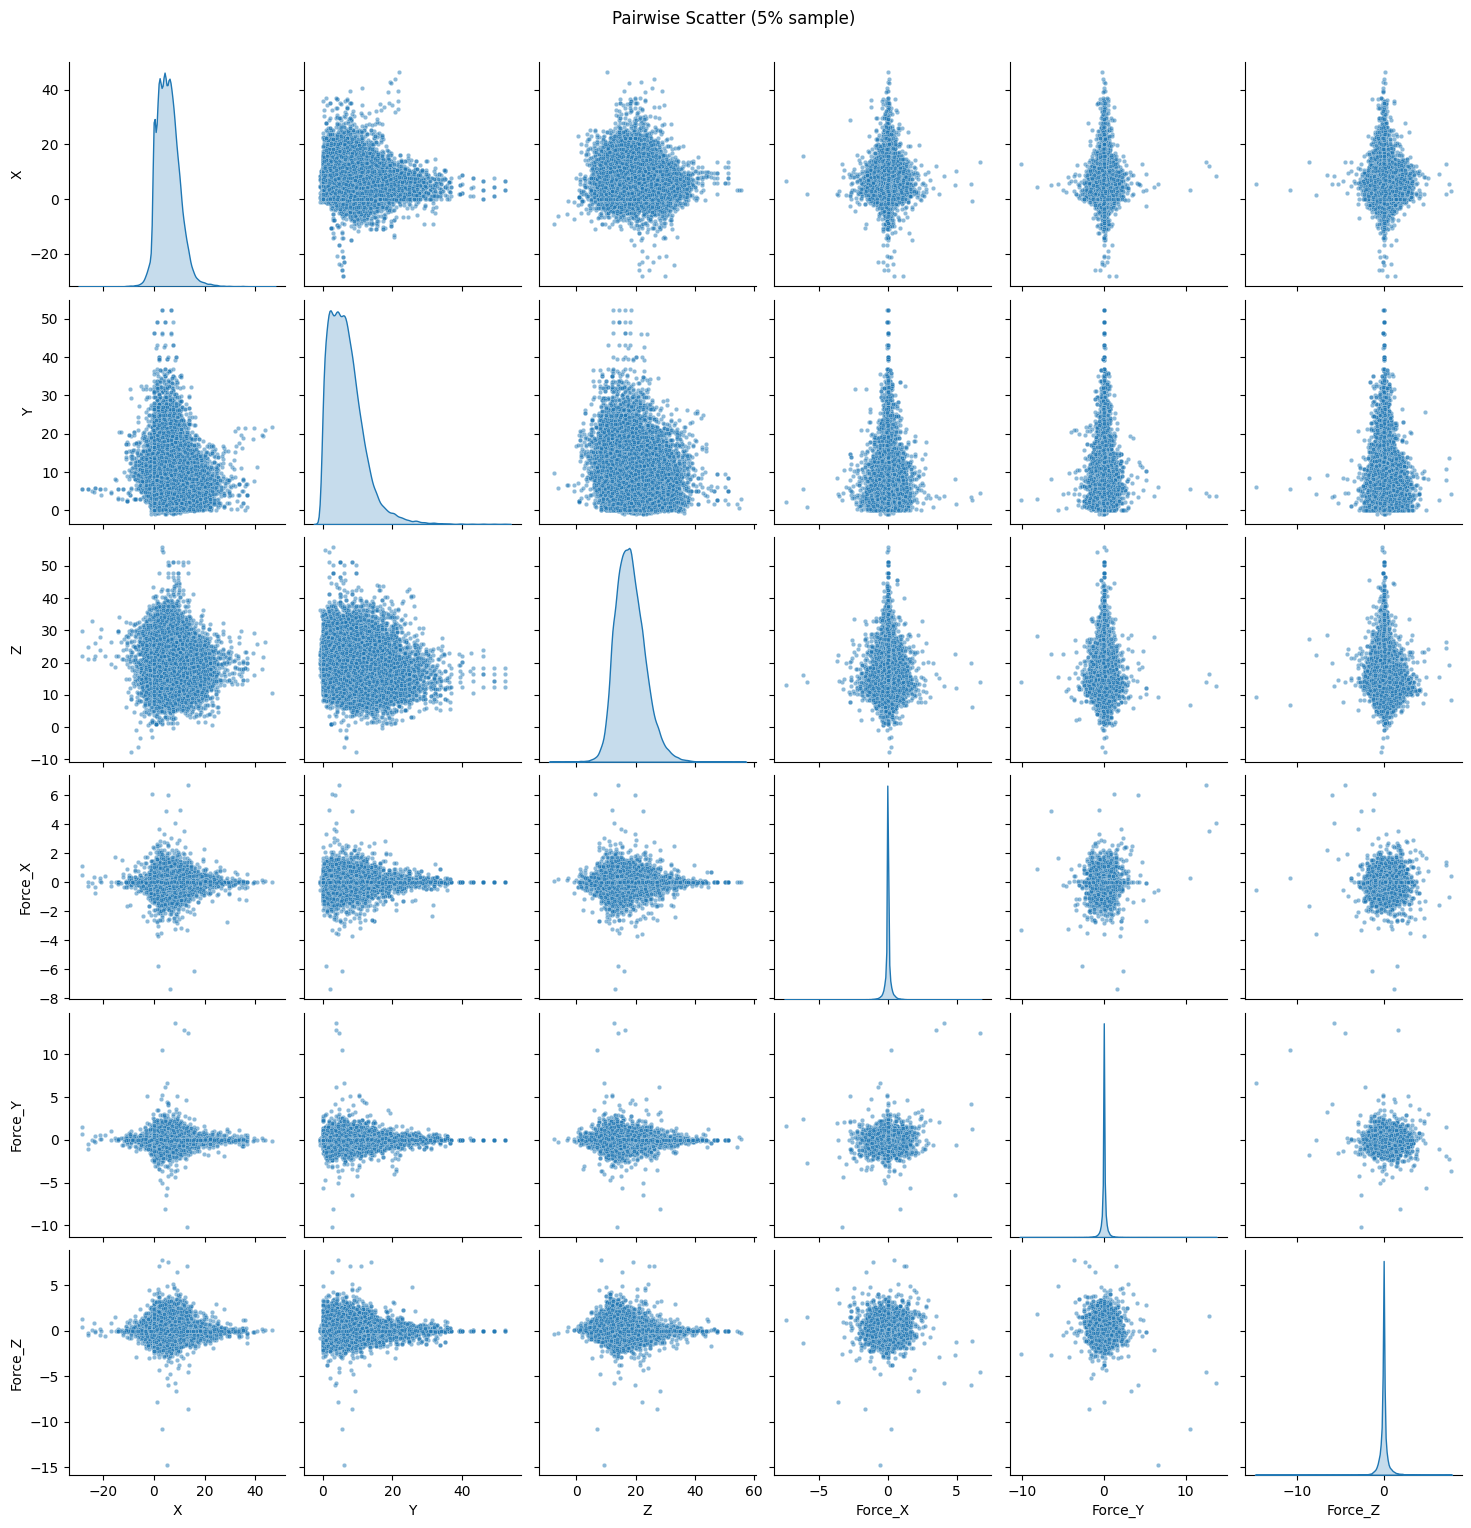

In [12]:
# 7. Pairwise scatter plots (sample 5% to save memory)
sample_frac = 0.5
df_sample = df[num_cols].sample(frac=sample_frac, random_state=42)
sns.pairplot(df_sample, diag_kind='kde', plot_kws={'alpha': 0.5, 's': 10})
plt.suptitle('Pairwise Scatter (5% sample)', y=1.02)
plt.show()

<ipython-input-13-4b84420a2266>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='Atom', data=df, order=df['Atom'].value_counts().index, palette="Set2")


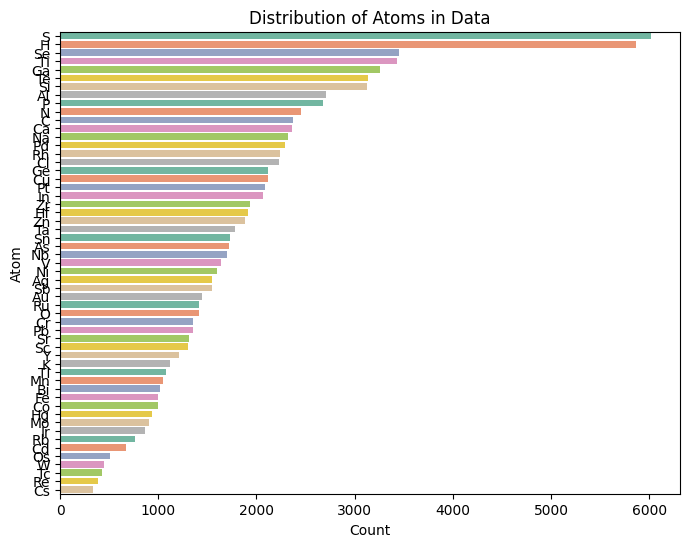

In [13]:
# 8. Atom type distribution
plt.figure(figsize=(8, 6))
sns.countplot(y='Atom', data=df, order=df['Atom'].value_counts().index, palette="Set2")
plt.title('Distribution of Atoms in Data')
plt.xlabel('Count')
plt.ylabel('Atom')
plt.show()


<ipython-input-14-d1e8ffcedea0>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Atom', y='Force_X', data=df, palette="Set1")


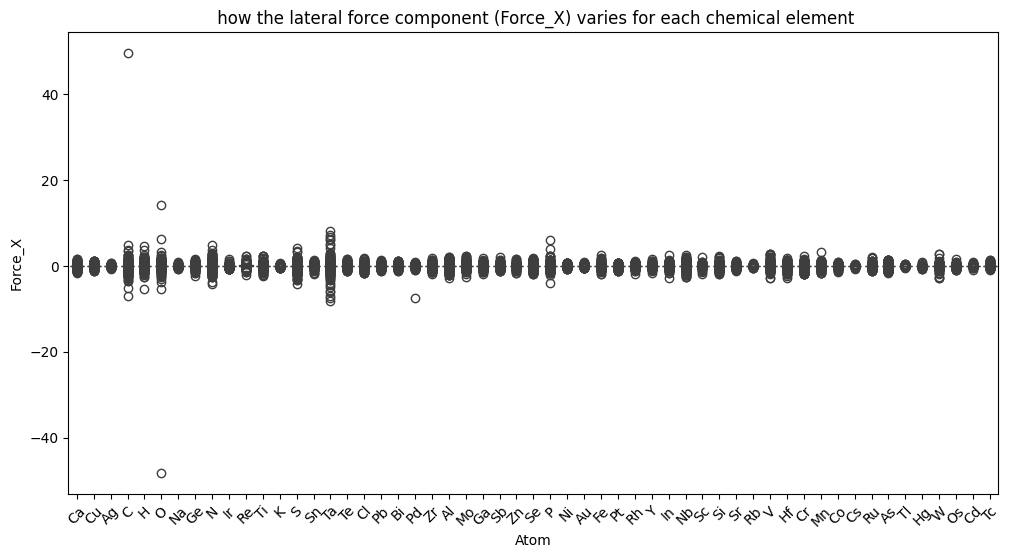

In [14]:
# 9. Force distribution by atom type (example: Force_X)
plt.figure(figsize=(12, 6))
sns.boxplot(x='Atom', y='Force_X', data=df, palette="Set1")
plt.title(' how the lateral force component (Force_X) varies for each chemical element')
plt.xticks(rotation=45)
plt.show()


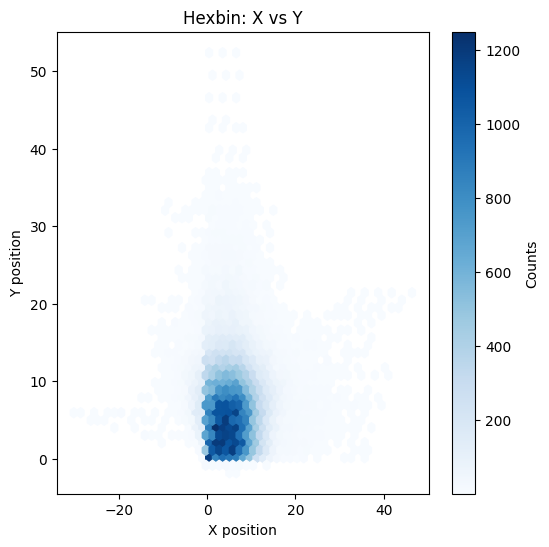

In [ ]:
# 11. Hexbin for atom positions (X vs Y)
plt.figure(figsize=(6, 6))
plt.hexbin(df['X'], df['Y'], gridsize=50, cmap='Blues', mincnt=1)
plt.title('Hexbin: X vs Y')
plt.xlabel('X position')
plt.ylabel('Y position')
cb = plt.colorbar()
cb.set_label('Counts')
plt.show()

The hexbin reveals that most atoms are clustered in a central region (roughly X ≈ 0–10, Y ≈ 0–10), with density tapering off toward the edges—highlighting a preferred adsorption zone on the catalyst surface.

# **Feature Engineering**

In [15]:
# 2. Define features and multi-output targets
feature_cols = ['X', 'Y', 'Z']
target_cols  = ['Force_X', 'Force_Y', 'Force_Z']

X = df[feature_cols]
y = df[target_cols]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
# 3. Fit a multi-output Decision Tree
dt = DecisionTreeRegressor(max_depth=70, random_state=42)
dt.fit(X_train, y_train)

# 4. Feature importances (aggregated over both outputs)
importances = pd.Series(dt.feature_importances_, index=feature_cols)\
                   .sort_values(ascending=False)
print("Feature Importances:\n", importances)



Feature Importances:
 Z    0.491055
Y    0.286614
X    0.222331
dtype: float64


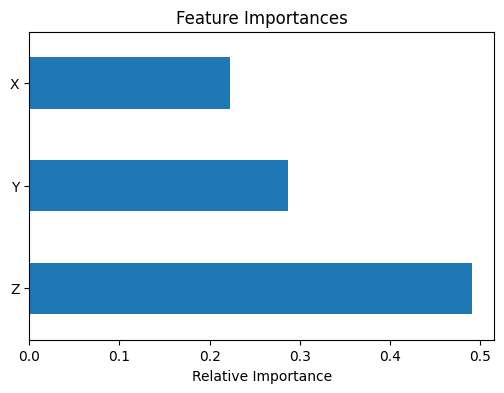

In [16]:

plt.figure(figsize=(6,4))
importances.plot(kind='barh')
plt.title("Feature Importances")
plt.xlabel("Relative Importance")
plt.show()


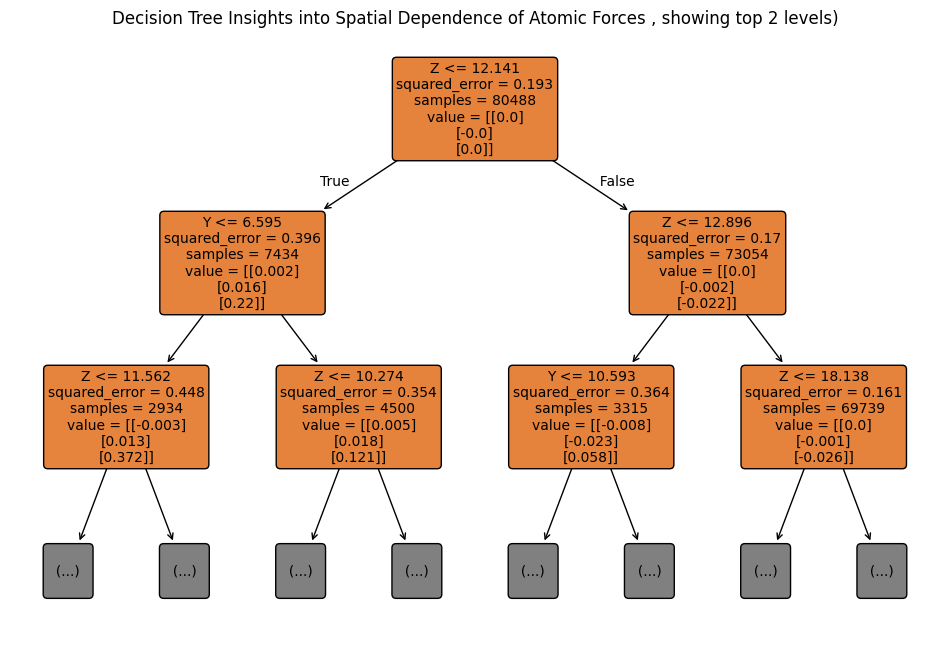

In [18]:
# 5. Visualize tree (top levels)
plt.figure(figsize=(12,8))
plot_tree(
    dt,
    feature_names=feature_cols,
    filled=True,
    rounded=True,
    max_depth=2,
    fontsize=10
)
plt.title("Decision Tree Insights into Spatial Dependence of Atomic Forces , showing top 2 levels)")
plt.show()



In [19]:
# 6. Evaluate on train (or hold-out) set

y_pred = dt.predict(X_test)

mse_Force_X     = mean_squared_error(y_test['Force_X'],     y_pred[:,0])
mse_Force_Y     = mean_squared_error(y_test['Force_Y'],     y_pred[:,1])
mse_Force_Z     = mean_squared_error(y_test['Force_Z'],     y_pred[:,2])

print(f"MSE Force_X: {mse_Force_X:.4f}")
print(f"MSE Force_Y: {mse_Force_Y:.4f}")
print(f"MSE Force_Z: {mse_Force_Z:.4f}")





MSE Force_X: 0.1680
MSE Force_Y: 0.2651
MSE Force_Z: 0.4395


# Using **PCA**

In [20]:
# 2. Select numeric features for PCA
numeric_cols = ['X', 'Y', 'Z', 'Force_X', 'Force_Y', 'Force_Z', 'Energy', 'Free_Energy']
X = df[numeric_cols]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Fit PCA
pca = PCA(n_components=5, random_state=42)
pca_components = pca.fit_transform(X_scaled)

# 5. Examine explained variance ratio
print("Explained variance ratio by component:", pca.explained_variance_ratio_)

# 6. Create DataFrame of PCA features
pca_cols = [f'PC{i+1}' for i in range(pca.n_components_)]
df_pca = pd.DataFrame(pca_components, columns=pca_cols, index=df.index)


Explained variance ratio by component: [0.2410455  0.18036324 0.13223591 0.12504111 0.11988044]


In [21]:
# 6. Create DataFrame of PCA features
pca_cols = [f'PC{i+1}' for i in range(pca.n_components_)]
df_pca = pd.DataFrame(pca_components, columns=pca_cols, index=df.index)


In [22]:
df_pca

,PC1,PC2,PC3,PC4,PC5
0,-0.482646,0.041535,0.097763,-1.145776,-1.203927
1,1.998767,-0.122689,-2.131413,-1.286109,-0.280475
2,0.732851,0.086879,-0.493999,-0.649239,-0.981657
3,0.241140,0.087416,-2.112878,-0.806138,0.411831
4,-1.853791,-0.086123,-0.872627,-1.192735,-0.527145
...,...,...,...,...,...
100605,0.608675,-1.223628,0.270116,0.040373,1.144756
100606,-0.549854,-0.052360,0.299582,0.139280,0.855477
100607,-1.515933,0.214754,0.320202,-0.109893,1.219143
100608,-1.164671,0.640233,0.088418,0.225914,1.172203


significantly simplifying our data (reducing from 8 to 5 dimensions) while preserving the majority of meaningful variation.

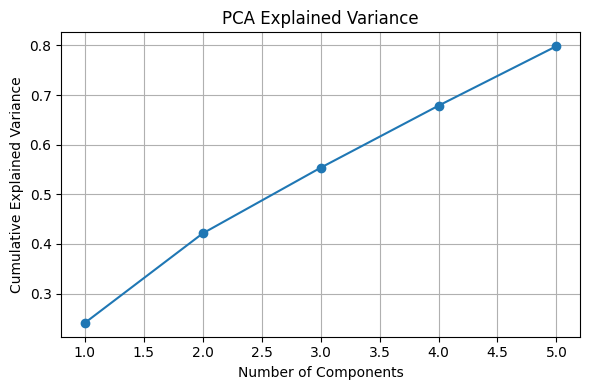

In [23]:
# 9. (Optional) Plot cumulative explained variance
plt.figure(figsize=(6,4))
plt.plot(range(1, len(pca.explained_variance_ratio_)+1),
         pca.explained_variance_ratio_.cumsum(), marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance')
plt.grid(True)
plt.tight_layout()
plt.show()

# **Modeling**

Random forest Regressor



*   feature importances to interpret what drives forces/energies.
*   Automatically captures non-linear couplings among coordinates, forces, and energies.



In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# 2. Features & target
feature_cols = ['X','Y','Z','Force_X','Force_Y','Energy','Free_Energy']
X = df[feature_cols]
y = df['Force_Z']

# 3. Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 4. Fit Random Forest
rf = RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42)
rf.fit(X_train, y_train)

# 5. Evaluate
y_pred = rf.predict(X_test)



In [ ]:
rmse = mean_squared_error(y_test, y_pred)
print(f"Random Forest RMSE (Force_Z): {rmse:.4f}")

# 6. Feature importances
importances = pd.Series(rf.feature_importances_, index=feature_cols)
print("Feature importances:\n", importances.sort_values(ascending=False))

Random Forest RMSE (Force_Z): 0.2304
Feature importances:
 Force_Y        0.341819
Force_X        0.239591
Z              0.154128
Y              0.103308
X              0.061196
Free_Energy    0.052514
Energy         0.047445
dtype: float64


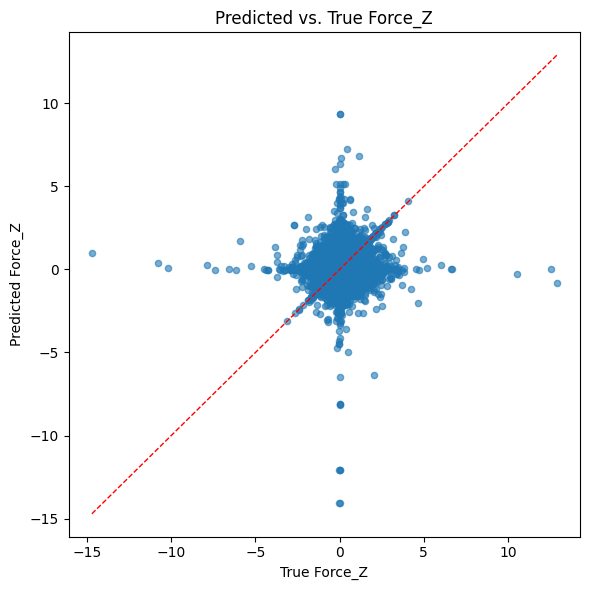

In [26]:
# ensure 1-D
y_true = y_test.values.flatten()
y_pred = y_pred.flatten()

plt.figure(figsize=(6,6))
plt.scatter(y_true, y_pred, alpha=0.6, s=20)
min_val = min(y_true.min(), y_pred.min())
max_val = max(y_true.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1)

plt.xlabel('True Force_Z')
plt.ylabel('Predicted Force_Z')
plt.title('Predicted vs. True Force_Z')
plt.tight_layout()
plt.show()

Gaussian Process Regression (GPR)

*   Provides both prediction and an uncertainty estimate
*   Uncertainty (y_std) guides where to run the next DFT calculation to maximize learning



In [27]:
import pandas as pd
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# 2. Features & target (example: predict Energy)
feature_cols = ['X','Y','Z','Force_X','Force_Y','Force_Z','Free_Energy']
X = df[feature_cols]
y = df['Energy']

# 3. Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)
# 3b. Further subsample the TRAINING portion to at most 2000 samples
max_train = 5000
if len(X_train) > max_train:
    X_sub, _, y_sub, _ = train_test_split(
        X_train, y_train,
        train_size=max_train, random_state=0
    )
else:
    X_sub, y_sub = X_train, y_train
# 4. Define kernel and fit GPR
kernel = ConstantKernel(1.0) * RBF(length_scale=1.0)
gpr = GaussianProcessRegressor(kernel=kernel, alpha=1e-4, normalize_y=True, random_state=0)
gpr.fit(X_sub, y_sub)


GaussianProcessRegressor(alpha=0.0001, kernel=1**2 * RBF(length_scale=1),
                         normalize_y=True, random_state=0)

In [28]:

# 5. Predict with uncertainty
y_mean, y_std = gpr.predict(X_test, return_std=True)
rmse = mean_squared_error(y_test, y_mean)
print(f"GPR RMSE (Energy): {rmse:.4f}")

# 6. Inspect a few uncertainty estimates
for i in range(5):
    print(f"Predicted={y_mean[i]:.3f} ± {y_std[i]:.3f},  True={y_test.values[i]:.3f}")


GPR RMSE (Energy): 3.1556
Predicted=-182.704 ± 2.545,  True=-185.468
Predicted=-180.075 ± 0.912,  True=-182.406
Predicted=-183.728 ± 1.349,  True=-181.993
Predicted=-184.885 ± 2.413,  True=-185.654
Predicted=-185.623 ± 1.533,  True=-184.417


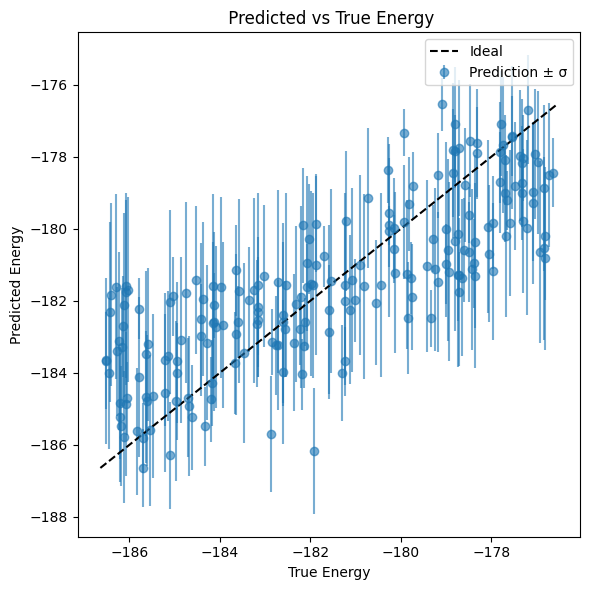

In [30]:
n_plot = 200
idx = np.random.choice(len(y_test), size=min(n_plot, len(y_test)), replace=False)
y_true_plot = y_test.values[idx]
y_pred_plot = y_mean[idx]
y_std_plot  = y_std[idx]

plt.figure(figsize=(6,6))
plt.errorbar(
    y_true_plot,
    y_pred_plot,
    yerr=y_std_plot,
    fmt='o',
    alpha=0.6,
    label='Prediction ± σ'
)
lims = [min(y_true_plot.min(), y_pred_plot.min()),
        max(y_true_plot.max(), y_pred_plot.max())]
plt.plot(lims, lims, 'k--', label='Ideal')
plt.xlabel('True Energy')
plt.ylabel('Predicted Energy')
plt.title(' Predicted vs True Energy')
plt.legend()
plt.tight_layout()
plt.show()


Predicted vs. True Energy with Uncertainty Bars

Points show true vs. predicted values, with vertical bars equal to the model’s σ.

The dashed line is the ideal y=x line.

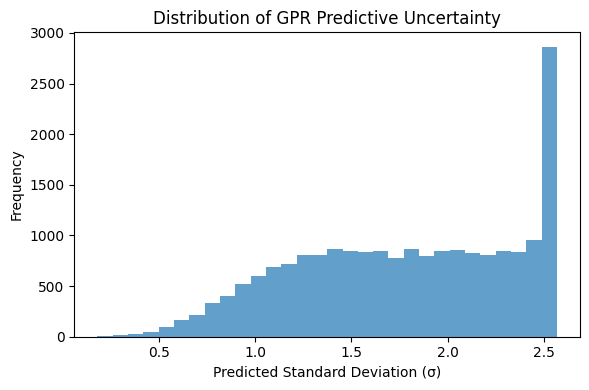

In [31]:
# 2) Histogram of predictive standard deviations
plt.figure(figsize=(6,4))
plt.hist(y_std, bins=30, alpha=0.7)
plt.xlabel('Predicted Standard Deviation (σ)')
plt.ylabel('Frequency')
plt.title('Distribution of GPR Predictive Uncertainty')
plt.tight_layout()
plt.show()

Histogram of Predictive Uncertainty

Reveals how confident the model is across the test set.

Helps choose a cutoff for “trustworthy” predictions.

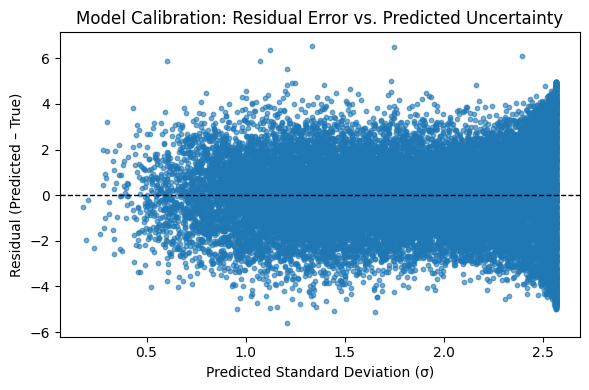

In [32]:
# 3) Residual vs. Predictive Uncertainty
residuals = y_mean - y_test.values
plt.figure(figsize=(6,4))
plt.scatter(y_std, residuals, alpha=0.6, s=10)
plt.axhline(0, color='k', linestyle='--', linewidth=1)
plt.xlabel('Predicted Standard Deviation (σ)')
plt.ylabel('Residual (Predicted – True)')
plt.title('Model Calibration: Residual Error vs. Predicted Uncertainty')
plt.tight_layout()
plt.show()

Residual vs. Predictive Uncertainty

Plots prediction error (residual) against predicted .

Ideally, larger errors should correspond to larger (positive correlation), showing the model knows when it’s likely to be wrong.

## Graph Neural Network - **GNN**

In [33]:
import pandas as pd
import numpy as np
import torch
!pip install torch_geometric
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors
from torch_geometric.nn import SAGEConv, BatchNorm
import matplotlib.pyplot as plt


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 23.9 MB/s eta 0:00:00


In [34]:
N = len(df)
# 2. Node features (6-d) & targets (3-d)
node_feats = df[['X','Y','Z','Free_Energy','Energy']].values
# add in-plane forces too?
node_feats = np.hstack([node_feats, df[['Force_X','Force_Y']].values])
targets    = df[['Force_X','Force_Y','Force_Z']].values

# 3. k-NN graph (k=8)
nbrs = NearestNeighbors(n_neighbors=16).fit(node_feats)
_, nn_idx = nbrs.kneighbors(node_feats)
edges = [[i,j] for i,neis in enumerate(nn_idx) for j in neis]
edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()

# 4. Train/test masks
idx = np.arange(N)
train_idx, test_idx = train_test_split(idx, test_size=0.2, random_state=42)
train_mask = torch.zeros(N, dtype=torch.bool); train_mask[train_idx] = True
test_mask  = torch.zeros(N, dtype=torch.bool); test_mask[test_idx]  = True

# 5. Build PyG data
data = Data(
    x=torch.tensor(node_feats, dtype=torch.float),
    edge_index=edge_index,
    y=torch.tensor(targets, dtype=torch.float),
    train_mask=train_mask,
    test_mask=test_mask
)

**GraphSAGE GNN for Multi-Component Force Prediction**
Below we define an improved GraphSAGE-based GNN (3 layers, batch norm, dropout) to predict the three force components for each atom. This architecture captures local neighbor interactions and regularizes across diverse catalytic environments.

In [35]:

class MultiForceGCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, num_layers=3):
        super().__init__()
        self.convs = torch.nn.ModuleList()
        self.bns   = torch.nn.ModuleList()
        # Input layer
        self.convs.append(SAGEConv(in_channels, hidden_channels))
        self.bns.append(BatchNorm(hidden_channels))
        # Hidden layers
        for _ in range(num_layers-2):
            self.convs.append(SAGEConv(hidden_channels, hidden_channels))
            self.bns.append(BatchNorm(hidden_channels))
        # Output layer
        self.convs.append(SAGEConv(hidden_channels, hidden_channels))
        self.bns.append(BatchNorm(hidden_channels))
        self.lin = torch.nn.Linear(hidden_channels, 3)

    def forward(self, x, edge_index):
        for conv, bn in zip(self.convs, self.bns):
            x = conv(x, edge_index)
            x = bn(x)
            x = F.relu(x)
            x = F.dropout(x, p=0.3, training=self.training)
        return self.lin(x)


**Training Loop with Early Stopping & LR Scheduler**
- We train for up to 100 epochs.
- Reduce learning rate on plateau and stop early after 10 epochs without improvement.
- This ensures robust generalization to new catalytic sites.

In [36]:
from torch_geometric.loader import DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = MultiForceGCN(in_channels=7, hidden_channels=128, num_layers=3).to(device)
data = data.to(device)
opt = torch.optim.Adam(model.parameters(), lr=5e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, factor=0.5, patience=5)

train_losses = []
test_losses  = []
best_test    = float('inf')
patience     = 0
for epoch in range(1, 101):
    model.train()
    opt.zero_grad()

    out = model(data.x, data.edge_index)                          # forward
    loss = F.mse_loss(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=2.0)  # gradient clipping
    opt.step()                                              # update weights

    model.eval()
    with torch.no_grad():
        pred = model(data.x, data.edge_index)
        test_loss = F.mse_loss(pred[data.test_mask], data.y[data.test_mask])

    # convert to floats for logging & early stopping
    train_mse = loss.item()
    test_mse  = test_loss.item()
    train_losses.append(train_mse)
    test_losses.append(test_mse)

    scheduler.step(test_mse)
    print(f"Epoch {epoch:03d}  Train MSE: {train_mse:.4f}  Test MSE: {test_mse:.4f}")

    # early stopping
    if test_mse < best_test:
        best_test = test_mse
        patience = 0
        torch.save(model.state_dict(), 'best_gcn.pth')
    else:
        patience += 1
        if patience >= 10:
            print("Early stopping.")
            break


Epoch 001  Train MSE: 0.4531  Test MSE: 50.3761
Epoch 002  Train MSE: 0.3977  Test MSE: 19.9244
Epoch 003  Train MSE: 0.3543  Test MSE: 11.0203
Epoch 004  Train MSE: 0.3374  Test MSE: 7.7774
Epoch 005  Train MSE: 0.3270  Test MSE: 6.1573
Epoch 006  Train MSE: 0.3217  Test MSE: 4.9014
Epoch 007  Train MSE: 0.3100  Test MSE: 3.8345
Epoch 008  Train MSE: 0.3038  Test MSE: 2.8055
Epoch 009  Train MSE: 0.2890  Test MSE: 1.9760
Epoch 010  Train MSE: 0.2855  Test MSE: 1.3659
Epoch 011  Train MSE: 0.2710  Test MSE: 0.9802
Epoch 012  Train MSE: 0.2821  Test MSE: 0.7406
Epoch 013  Train MSE: 0.2691  Test MSE: 0.5993
Epoch 014  Train MSE: 0.2634  Test MSE: 0.4887
Epoch 015  Train MSE: 0.2638  Test MSE: 0.4221
Epoch 016  Train MSE: 0.2560  Test MSE: 0.3626
Epoch 017  Train MSE: 0.2524  Test MSE: 0.3146
Epoch 018  Train MSE: 0.2464  Test MSE: 0.2783
Epoch 019  Train MSE: 0.2452  Test MSE: 0.2528
Epoch 020  Train MSE: 0.2471  Test MSE: 0.2351
Epoch 021  Train MSE: 0.2364  Test MSE: 0.2215
Epoch 022 

**Visualizing Loss Curves**
Plotting train vs. test MSE to monitor convergence and detect overfitting. A small gap indicates good generalization across diverse atomic configurations.

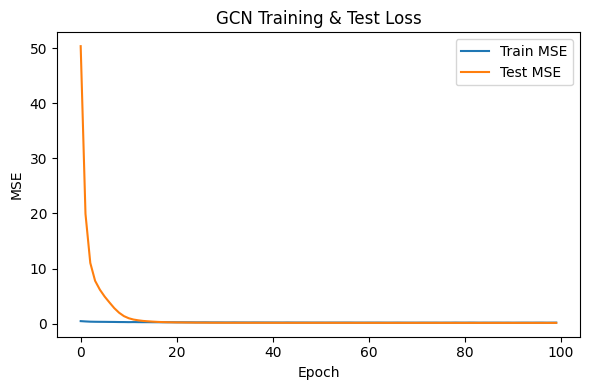

In [37]:
# 8a. Plot training & test loss curves
plt.figure(figsize=(6,4))
plt.plot(train_losses, label='Train MSE')
plt.plot(test_losses,  label='Test MSE')
plt.xlabel('Epoch'); plt.ylabel('MSE')
plt.title('GCN Training & Test Loss')
plt.legend(); plt.tight_layout()
plt.show()


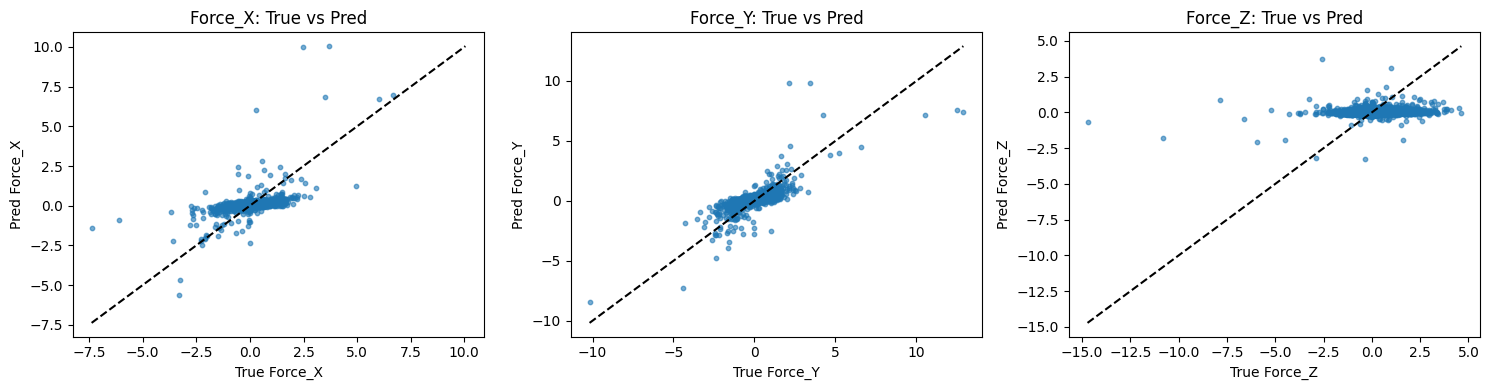

In [39]:
 #8b. Scatter: true vs predicted for each force component
model.eval()
with torch.no_grad():
    preds = model(data.x, data.edge_index).cpu().numpy()
trues = data.y.cpu().numpy()

fig, axes = plt.subplots(1, 3, figsize=(15,4))
comps = ['Force_X','Force_Y','Force_Z']
for i, comp in enumerate(comps):
    axes[i].scatter(trues[test_idx,i], preds[test_idx,i], alpha=0.6, s=10)
    mn = min(trues[test_idx,i].min(), preds[test_idx,i].min())
    mx = max(trues[test_idx,i].max(), preds[test_idx,i].max())
    axes[i].plot([mn,mx],[mn,mx],'k--')
    axes[i].set_xlabel(f'True {comp}')
    axes[i].set_ylabel(f'Pred {comp}')
    axes[i].set_title(f'{comp}: True vs Pred')
plt.tight_layout(); plt.show()